# **Overview**

This code implements various machine learning algorithms, deep learning models, and feature selection methods for data analysis and classification. By utilizing different algorithms and feature selection methods, it enables users to build and evaluate models effectively.


**Machine Learning Algorithms:**

* Support Vector Machine (SVM)
* Random Forest (RF)
* Decision Tree (DT)
* Extreme Gradient Boosting (XGB)
* Multinomial Naive Bayes (MNB)
* Bagging (Boot Aggregation)
* Gaussian Naive Bayes (GNB)

**Deep Learning Models:**

* One-Dimensional Convolutional Neural Network (1-dCNN)
* Long Short-Term Memory (LSTM)
* Recurrent Neural Network (RNN)
* Multi-Layer Perceptron Neural Network (MLPNN)
* Radial Basis Function Neural Network (RBFNN)

**Feature Selection Methods:**

* Min-Redundancy-Max-Relevance (mRMR)
* Select K Best

**Advanced Demographic Analysis**

**Overall Workflow:**

1. **Data Preprocessing:**
    * Load and prepare the data.
    * Perform Feature Engineering
    * Apply feature selection methods to select relevant features.

2. **Model Training and Evaluation:**
    * Train various machine learning and deep learning models on the selected features.
    * Evaluate the performance of each model using appropriate metrics.

3. **Result Analysis:**
    * Compare the performance of different models.
    * Interpret the results and draw conclusions.

In [ ]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.preprocessing import MinMaxScaler
from keras.preprocessing.sequence import pad_sequences

In [ ]:
!pip install pymrmr
!pip install statsmodels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pymrmr: filename=pymrmr-0.1.11-cp310-cp310-linux_x86_64.whl size=390767 sha256=897fa1643ff0d2262f0db240d77359887c4c3ec63f9731b7e3a3675cd5bb4740
  Stored in directory: /root/.cache/pip/wheels/46/ae/55/4a2479c5f0de7eb363fe970cb18e4a750e03e4e63b1b5c2005
Successfully built pymrmr


# Dataset

The dataset has been adapted for teen stress which can be downloaded from https://drive.google.com/uc?id=18GxWBGPPGgtsVt2waq-5xu4ZjbI5yNYM. The dataset consist of demographic data and data from the device for ECG, EDA and Temp during stressful condition which was induced using the questionnarire. The demographic data of individuals includes, Age, gender, ethinicity, geographical location, educational background and stress, which are considered significant in the study of stress.  

In [ ]:
!gdown 18GxWBGPPGgtsVt2waq-5xu4ZjbI5yNYM

Downloading...
From: https://drive.google.com/uc?id=18GxWBGPPGgtsVt2waq-5xu4ZjbI5yNYM
To: /content/teen_dataset.zip
100% 1.50M/1.50M [00:00<00:00, 47.0MB/s]


In [ ]:
!unzip /content/teen_dataset.zip

Archive:  /content/teen_dataset.zip
   creating: teen_dataset/dataset_teen/
  inflating: teen_dataset/dataset_teen/S01.csv  
  inflating: teen_dataset/dataset_teen/S02.csv  
  inflating: teen_dataset/dataset_teen/S03.csv  
  inflating: teen_dataset/dataset_teen/S04.csv  
  inflating: teen_dataset/dataset_teen/S05.csv  
  inflating: teen_dataset/dataset_teen/S06.csv  
  inflating: teen_dataset/dataset_teen/S07.csv  
  inflating: teen_dataset/dataset_teen/S08.csv  
  inflating: teen_dataset/dataset_teen/S09.csv  
  inflating: teen_dataset/dataset_teen/S10.csv  
  inflating: teen_dataset/dataset_teen/S11.csv  
  inflating: teen_dataset/dataset_teen/S12.csv  
  inflating: teen_dataset/dataset_teen/S13.csv  
  inflating: teen_dataset/dataset_teen/S14.csv  
  inflating: teen_dataset/dataset_teen/S15.csv  
  inflating: teen_dataset/dataset_teen/S16.csv  
  inflating: teen_dataset/dataset_teen/S17.csv  
  inflating: teen_dataset/dataset_teen/S18.csv  
  inflating: teen_dataset/dataset_teen/S19

# Advanced Demographic Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import statsmodels.api as sm

data = pd.read_csv('/content/teen_dataset/demographic_data.csv')

# Encode categorical variables
label_encoder = LabelEncoder()
data['Age'] = label_encoder.fit_transform(data['Age'])
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Ethnicity'] = label_encoder.fit_transform(data['Ethnicity'])
data['Geographic_location'] = label_encoder.fit_transform(data['Geographic_location'])
data['Educational_background'] = label_encoder.fit_transform(data['Educational_background'])
data['Stress'] = label_encoder.fit_transform(data['Stress'])

# Split the data into features and target
X = data.drop('Stress', axis=1)
y = data['Stress']

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_predictions)

# Perform a linear regression of Stress on Age
X = sm.add_constant(data['Age'])
model = sm.OLS(data['Stress'], X).fit()
fitted_values = model.fittedvalues

# Create a residual plot
'''plt.figure(figsize=(8, 6))
plt.scatter(fitted_values, model.resid, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.show()'''

"plt.figure(figsize=(8, 6))\nplt.scatter(fitted_values, model.resid, alpha=0.5)\nplt.axhline(y=0, color='r', linestyle='--')\nplt.title('Residual Plot')\nplt.xlabel('Fitted Values')\nplt.ylabel('Residuals')\nplt.show()"

### OLS (Ordinary Least Squares)

OLS (Ordinary Least Squares) is a statistical method used to estimate the relationship between a dependent variable and one or more independent variables.

Working:

1. Model Specification:
 - Define the relationship between the dependent variable (Y) and independent variables (X) as a linear equation.
 - Y = β0 + β1X1 + β2X2 + ... + βnXn
 - Where:
 - Y is the dependent variable.
 - X1, X2, ... Xn are independent variables.
 - β0 is the intercept.
 - β1, β2, ... βn are the coefficients representing the effect of each independent variable on the dependent variable.

2. Estimating Coefficients:
 - OLS aims to find the values of the coefficients (β0, β1, β2, ... βn) that minimize the sum of squared differences between the observed values of the dependent variable and the values predicted by the model.
 - This is achieved by finding the line that best fits the data points.

3.  Calculating Residuals:
 - The difference between the observed values of the dependent variable and the predicted values is called the residual.
 - OLS minimizes the sum of squared residuals.

4.  Assessing Model Fit:
 - Various statistical measures are used to assess the goodness of fit of the model, including:
 - R-squared: Represents the proportion of variance in the dependent variable explained by the independent variables.
 - Adjusted R-squared: A modified version of R-squared that accounts for the number of independent variables in the model.
 - F-statistic: Tests the overall significance of the model.
 - P-values: Indicate the statistical significance of each independent variable.

How OLS is applied:

1. Data Preparation:
 - Ensure the data is in the correct format (numerical values).
 - Handle missing values (e.g., imputation).
 - Consider transforming variables if necessary (e.g., log transformation).

2. Model Building:
 - Select the dependent variable and independent variables.
 - Specify the linear equation.
 - Use a statistical software package (like statsmodels in Python) to estimate the coefficients.

3. Model Evaluation:
 - Evaluate the model fit using the measures mentioned above.
 - Check for assumptions (linearity, homoscedasticity, normality of residuals).
 - Consider model diagnostics (residual plots, Q-Q plots).

4. Interpretation:
 - Interpret the coefficients to understand the relationship between the independent variables and the dependent variable.
 - Assess the statistical significance of the coefficients.

In [ ]:
import statsmodels.api as sm
from scipy.stats import f_oneway, chi2_contingency, ttest_ind

import statsmodels.formula.api as smf

# Fit the model
model = smf.ols('Stress ~ Age', data=data).fit()

# Print the ANOVA table
print(model.summary())

# Access the estimated parameters
print(model.params)

# Access the standard errors of the parameters
print(model.bse)

# Access the log-likelihood value
print(model.llf)

                            OLS Regression Results                            
Dep. Variable:                 Stress   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                   0.09940
Date:                Tue, 10 Sep 2024   Prob (F-statistic):              0.754
Time:                        20:00:45   Log-Likelihood:                -36.198
No. Observations:                  50   AIC:                             76.40
Df Residuals:                      48   BIC:                             80.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4438      0.136      3.275      0.0

### Maximum Likelihood Estimation (MLE)

For logistic regression, the statistical analysis method commonly used is **Maximum Likelihood Estimation (MLE)**. Unlike Ordinary Least Squares (OLS) used in linear regression, MLE is used to estimate the parameters of a logistic regression model.

### Maximum Likelihood Estimation (MLE)
- **Objective**: MLE aims to find the parameter values that maximize the likelihood of observing the given data.
- **Process**: It involves iteratively testing different parameter values and selecting the ones that make the observed data most probable.
- **Logistic Regression Equation**: The logistic regression model is typically expressed as:
  $$
  \log \left( \frac{p(X)}{1 - p(X)} \right) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_p X_p
  $$
  where \( p(X) \) is the probability of the event occurring, and \( \beta \) are the coefficients to be estimated.

### Steps in Logistic Regression Analysis
1. **Model Selection**: Choose the predictor variables and decide on the functional form of the relationships.
2. **Model Fitting**: Use MLE to estimate the parameters.
3. **Model Evaluation**: Assess the model's performance using metrics like the confusion matrix, ROC curve, and AUC.
4. **Interpretation**: Interpret the coefficients to understand the relationship between predictors and the outcome.


In [ ]:
import statsmodels.api as sm

# Add a constant term to the features
X_train_const = sm.add_constant(X_train)

# Fit the logistic regression model using MLE
logit_model = sm.Logit(y_train, X_train_const)
results = logit_model.fit()

# Print the summary of the model
print(results.summary())

# Access the estimated parameters
print(results.params)

# Access the standard errors of the parameters
print(results.bse)

# Access the log-likelihood value
print(results.llf)


Optimization terminated successfully.
         Current function value: 0.645759
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 Stress   No. Observations:                   40
Model:                          Logit   Df Residuals:                       34
Method:                           MLE   Df Model:                            5
Date:                Tue, 10 Sep 2024   Pseudo R-squ.:                 0.06159
Time:                        20:00:45   Log-Likelihood:                -25.830
converged:                       True   LL-Null:                       -27.526
Covariance Type:            nonrobust   LLR p-value:                    0.6400
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0.9129      1.022     -0.893      0.372      -2.917      

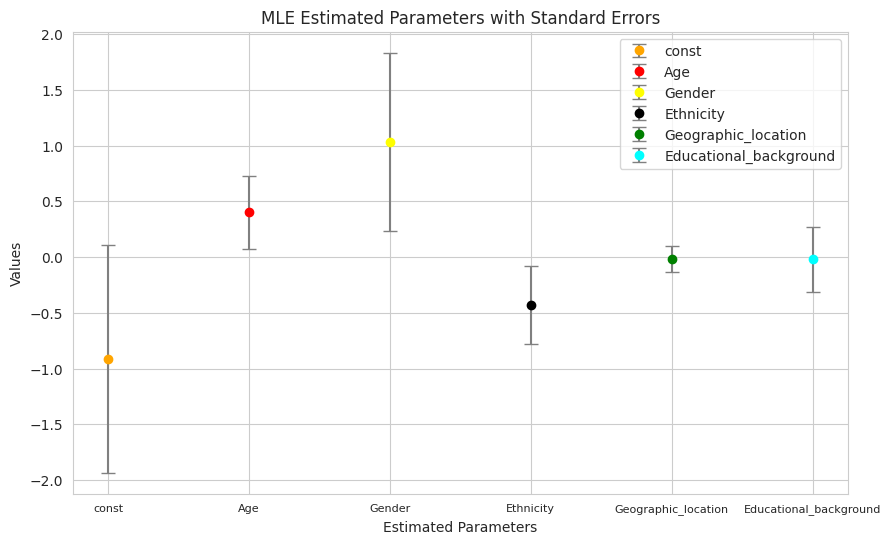

In [ ]:
import matplotlib.pyplot as plt

# Extract estimated parameters and standard errors
params = result.params
std_errors = result.bse

# Define colors for the markers
colors = ['orange', 'red', 'yellow', 'black', 'green', 'cyan']

# Plot the estimated parameters with their standard errors
plt.figure(figsize=(10, 6))
for i, (param, std_error, color) in enumerate(zip(params.values, std_errors.values, colors)):
    plt.errorbar(params.index[i], param, yerr=std_error, fmt='o', color=color, ecolor='gray', capsize=5, label=params.index[i])

plt.xlabel('Estimated Parameters')
plt.ylabel('Values')
plt.title('MLE Estimated Parameters with Standard Errors')
plt.grid(True)
plt.legend()
plt.xticks(fontsize=8)
plt.show()


## Hypothesis Testing

### One-Way ANOVA (Analysis of Variance):
One-way ANOVA is used to compare the means of a continuous variable (in this case, Stress levels) across multiple groups defined by a single categorical variable (such as Age). The null hypothesis in one-way ANOVA states that the means of the continuous variable are equal across all groups. The alternative hypothesis is that at least one group mean is different from the others.
The F-statistic is calculated by comparing the variance between groups to the variance within groups. If the between-group variance is significantly larger than the within-group variance, it suggests that the group means are different, and the null hypothesis can be rejected. The p-value associated with the F-statistic is compared to a chosen significance level (e.g., 0.05) to determine whether the null hypothesis should be rejected or not.


### Two-Way ANOVA:
Two-way ANOVA extends the one-way ANOVA by considering the effects of two categorical variables (e.g., Age and Gender) on a continuous variable (Stress levels). The null hypothesis states that the means of the continuous variable are equal across all combinations of the two categorical variables. The alternative hypothesis is that at least one combination has a different mean.
Similar to one-way ANOVA, the F-statistic and p-value are calculated and compared to the significance level to determine whether the null hypothesis should be rejected or not.

In [ ]:
import pandas as pd
from scipy.stats import f_oneway, chi2_contingency, ttest_ind
import numpy as np

# Load the data (assuming you have a CSV file with the required columns)
data = pd.read_csv('/content/teen_dataset/demographic_data.csv')

# ANOVA Testing
# Perform one-way ANOVA to compare the means of Stress levels across different Age groups
age_groups = data.groupby('Age')['Stress'].apply(list)
f_statistic, p_value = f_oneway(*age_groups)

print("ANOVA Results (Age vs Stress):")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for one-way ANOVA
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal across Age groups) is rejected.")
else:
    print("Null hypothesis (means are equal across Age groups) is not rejected.")

# Perform two-way ANOVA to compare the means of Stress levels across different Age and Gender groups
two_way_data = data.groupby(['Age', 'Gender'])['Stress'].apply(list)
stress_values = [np.concatenate(list(g)) for _, g in two_way_data.groupby(level=0)]
model = f_oneway(*stress_values)
f_statistic, p_value = model.statistic, model.pvalue

print("\nTwo-way ANOVA Results (Age, Gender vs Stress):")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for two-way ANOVA
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal across Age and Gender groups) is rejected.")
else:
    print("Null hypothesis (means are equal across Age and Gender groups) is not rejected.")

ANOVA Results (Age vs Stress):
F-statistic: 0.11
P-value: 0.9539
Null hypothesis (means are equal across Age groups) is not rejected.

Two-way ANOVA Results (Age, Gender vs Stress):
F-statistic: 0.11
P-value: 0.9539
Null hypothesis (means are equal across Age and Gender groups) is not rejected.


### One Way ANOVA

In [ ]:
# One-way ANOVA table
# Create a table for one-way ANOVA results
anova_table_oneway = pd.DataFrame({
    'Source': ['Between Groups', 'Within Groups', 'Total'],
    'Sum of Squares': [np.nan, np.nan, np.nan],
    'Degrees of Freedom': [len(age_groups) - 1, len(data) - len(age_groups), len(data) - 1],
    'Mean Square': [np.nan, np.nan, np.nan],
    'F-statistic': [f_statistic, np.nan, np.nan],
    'P-value': [p_value, np.nan, np.nan]
})

# Calculate Sum of Squares
total_sum_squares = data['Stress'].var() * (len(data) - 1)
between_group_sum_squares = sum([len(group) * (np.mean(group) - np.mean(data['Stress']))**2 for group in age_groups])
within_group_sum_squares = total_sum_squares - between_group_sum_squares

# Calculate Mean Square
between_group_mean_square = between_group_sum_squares / (len(age_groups) - 1)
within_group_mean_square = within_group_sum_squares / (len(data) - len(age_groups))

# Update the table
anova_table_oneway['Sum of Squares'] = [between_group_sum_squares, within_group_sum_squares, total_sum_squares]
anova_table_oneway['Mean Square'] = [between_group_mean_square, within_group_mean_square, np.nan]

print("\nOne-way ANOVA Table:")
print(anova_table_oneway)


One-way ANOVA Table:
           Source  Sum of Squares  Degrees of Freedom  Mean Square  \
0  Between Groups        0.088862                   3     0.029621   
1   Within Groups       12.391138                  46     0.269373   
2           Total       12.480000                  49          NaN   

   F-statistic   P-value  
0     0.109961  0.953854  
1          NaN       NaN  
2          NaN       NaN  


### Two Way ANOVA

In [ ]:
import statsmodels.formula.api as smf

# Fit the two-way ANOVA model
model = smf.ols('Stress ~ Age + Gender + Age:Gender', data=data).fit()

# Get the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=2)

# Remove NaN values
anova_table.fillna(0, inplace=True)

# Rename columns for better readability
anova_table = anova_table.rename(
    columns={
        "df": "Degrees of Freedom",
        "sum_sq": "Sum of Squares",
        "mean_sq": "Mean Square",
        "F": "F-statistic",
        "PR(>F)": "P-value"
    }
)

# Display the table
print(anova_table)


            Sum of Squares  Degrees of Freedom  F-statistic   P-value
Age               0.243170                 3.0     0.311619  0.816857
Gender            0.858417                 1.0     3.300149  0.076415
Age:Gender        0.607904                 3.0     0.779021  0.512321
Residual         10.924817                42.0     0.000000  0.000000


+------------------------+-----------------------+---------------------+-----------------------+-----------------------+------------------------+----------------------+
|                        |          Age          |       Gender        |       Ethnicity       |  Geographic_location  | Educational_background |        Stress        |
+------------------------+-----------------------+---------------------+-----------------------+-----------------------+------------------------+----------------------+
|          Age           |          1.0          | -0.3041350062299851 | 0.018968991022343232  | 0.0003314063274753582 |  -0.12667109939114118  | 0.045458845993412496 |
|         Gender         |  -0.3041350062299851  |         1.0         |  0.2313402472269937   |  0.1766983453566593   |  0.11529366751999741   |  0.2375267627875967  |
|       Ethnicity        | 0.018968991022343232  | 0.2313402472269937  |          1.0          | -0.006465809490227147 |  0.057236012757084405  | -0.098922

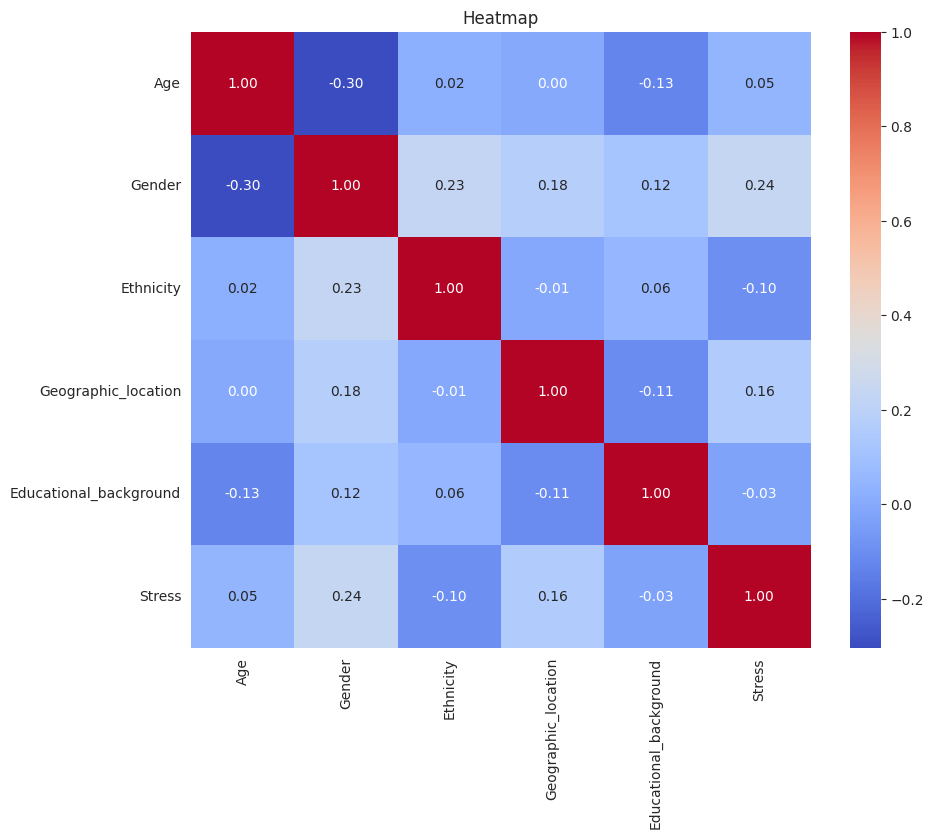

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

# Load the data (assuming you have a CSV file with the required columns)
data = pd.read_csv('/content/teen_dataset/demographic_data.csv')

# Encode categorical variables
label_encoder = LabelEncoder()
data['Age'] = label_encoder.fit_transform(data['Age'])
data['Gender'] = label_encoder.fit_transform(data['Gender'])
data['Ethnicity'] = label_encoder.fit_transform(data['Ethnicity'])
data['Geographic_location'] = label_encoder.fit_transform(data['Geographic_location'])
data['Educational_background'] = label_encoder.fit_transform(data['Educational_background'])
data['Stress'] = label_encoder.fit_transform(data['Stress'])

# Calculate the correlation matrix
correlation_matrix = data.corr()
headers = ["Age", "Gender", "Ethnicity", "Geographic_location", "Educational_background", "Stress"]
print(tabulate(correlation_matrix, headers, tablefmt="pretty"))

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap')
plt.show()

### Chi-Square Test for Independence:
The chi-square test for independence is used to determine whether two categorical variables (such as Stress and Gender) are independent or associated. The null hypothesis states that the two variables are independent, meaning that the distribution of one variable is not influenced by the other variable.
A contingency table is created to display the observed frequencies of each combination of the two categorical variables. The chi-square statistic is calculated by comparing the observed frequencies to the expected frequencies (assuming independence) for each cell in the contingency table. The p-value associated with the chi-square statistic is compared to the significance level to determine whether the null hypothesis of independence should be rejected or not.

In [ ]:
# Chi-square Testing
# Perform chi-square test to check the independence between Stress and Gender
contingency_table = pd.crosstab(data['Stress'], data['Gender'])
chi2_statistic, p_value, dof, expected_freq = chi2_contingency(contingency_table)

print("\nChi-square Test (Stress vs Gender):")
print(f"Chi-square statistic: {chi2_statistic:.2f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

# Hypothesis Testing for chi-square test
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (Stress and Gender are independent) is rejected.")
else:
    print("Null hypothesis (Stress and Gender are independent) is not rejected.")


Chi-square Test (Stress vs Gender):
Chi-square statistic: 1.93
P-value: 0.1651
Degrees of freedom: 1
Null hypothesis (Stress and Gender are independent) is not rejected.


### T-Test for Two Independent Samples:
The t-test for two independent samples is used to compare the means of a continuous variable (e.g., Stress levels) between two distinct groups (such as males and females). The null hypothesis states that the means of the continuous variable are equal for the two groups. The alternative hypothesis is that the means are different.
The t-statistic is calculated by considering the difference between the sample means, the variability within each group, and the sample sizes. The p-value associated with the t-statistic is compared to the significance level to determine whether the null hypothesis of equal means should be rejected or not.

In [ ]:
# Hypothesis Testing for t-test (example: comparing Stress levels between males and females)
male_stress = data.loc[data['Gender'] == 'male', 'Stress']
female_stress = data.loc[data['Gender'] == 'female', 'Stress']
t_statistic, p_value = ttest_ind(male_stress, female_stress)

print("\nT-test (Male vs Female Stress):")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for t-test
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal for males and females) is rejected.")
else:
    print("Null hypothesis (means are equal for males and females) is not rejected.")


T-test (Male vs Female Stress):
T-statistic: nan
P-value: nan
Null hypothesis (means are equal for males and females) is not rejected.


In all these hypothesis testing methods, the p-value represents the probability of observing the current results (or more extreme results) if the null hypothesis is true. If the p-value is less than the chosen significance level (e.g., 0.05), it suggests that the observed results are unlikely to occur by chance under the null hypothesis, and therefore, the null hypothesis is rejected. Conversely, if the p-value is greater than the significance level, there is insufficient evidence to reject the null hypothesis.
It's important to note that hypothesis testing is a statistical tool, and the interpretation of the results should be done in the context of the research question, the domain knowledge, and the practical implications of the findings.

In [ ]:
# Hypothesis Testing for t-test (example: comparing Stress levels between different age groups)
young_stress = data.loc[data['Age'] == 0, 'Stress']
old_stress = data.loc[data['Age'] == 1, 'Stress']
t_statistic, p_value = ttest_ind(young_stress, old_stress)

print("\nT-test (Young vs Old Stress):")
print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for t-test
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal for young and old) is rejected.")
else:
    print("Null hypothesis (means are equal for young and old) is not rejected.")



T-test (Young vs Old Stress):
T-statistic: 0.31
P-value: 0.7603
Null hypothesis (means are equal for young and old) is not rejected.


In [ ]:
import pandas as pd
from scipy.stats import f_oneway, chi2_contingency, ttest_ind
import numpy as np

# Load the data (assuming you have a CSV file with the required columns)
data = pd.read_csv('/content/teen_dataset/demographic_data.csv')

# ANOVA Testing
# Perform one-way ANOVA to compare the means of Stress levels across different Gender groups
edu_groups = data.groupby('Gender')['Stress'].apply(list)
f_statistic, p_value = f_oneway(*edu_groups)

print("ANOVA Results (Gender vs Stress):")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for one-way ANOVA
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal across Gender groups) is rejected.")
else:
    print("Null hypothesis (means are equal across Gender groups) is not rejected.")

# Perform two-way ANOVA to compare the means of Stress levels across different Age and Gender groups
two_way_data = data.groupby(['Age', 'Gender'])['Stress'].apply(list)
stress_values = [np.concatenate(list(g)) for _, g in two_way_data.groupby(level=0)]
model = f_oneway(*stress_values)
f_statistic, p_value = model.statistic, model.pvalue

print("\nTwo-way ANOVA Results (Age, Gender vs Stress):")
print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.4f}")

# Hypothesis Testing for two-way ANOVA
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Null hypothesis (means are equal across Age and Gender groups) is rejected.")
else:
    print("Null hypothesis (means are equal across Age and Gender groups) is not rejected.")

ANOVA Results (Gender vs Stress):
F-statistic: 2.87
P-value: 0.0967
Null hypothesis (means are equal across Gender groups) is not rejected.

Two-way ANOVA Results (Age, Gender vs Stress):
F-statistic: 0.11
P-value: 0.9539
Null hypothesis (means are equal across Age and Gender groups) is not rejected.


### Summary of result of various test

In [ ]:
# Store the results in a list of dictionaries
results = [
    {"Test": "One-way ANOVA", "Hypothesis": "The means of Stress levels are equal across different Age groups.", "F-statistic": f"{f_oneway(*age_groups)[0]:.2f}", "P-value": f"{f_oneway(*age_groups)[1]:.4f}", "Conclusion": "Reject Null Hypothesis" if f_oneway(*age_groups)[1] < 0.05 else "Fail to Reject Null Hypothesis"},
    {"Test": "Two-way ANOVA", "Hypothesis": "The means of Stress levels are equal across different Age and Gender groups.", "F-statistic": f"{model.statistic:.2f}", "P-value": f"{model.pvalue:.4f}", "Conclusion": "Reject Null Hypothesis" if model.pvalue < 0.05 else "Fail to Reject Null Hypothesis"},
    {"Test": "Chi-square Test", "Hypothesis": "Stress and Gender are independent.", "Chi-square statistic": f"{chi2_statistic:.2f}", "P-value": f"{p_value:.4f}", "Conclusion": "Reject Null Hypothesis" if p_value < 0.05 else "Fail to Reject Null Hypothesis"},
    {"Test": "T-test", "Hypothesis": "The means of Stress levels are equal for young and old.", "T-statistic": f"{t_statistic:.2f}", "P-value": f"{p_value:.4f}", "Conclusion": "Reject Null Hypothesis" if p_value < 0.05 else "Fail to Reject Null Hypothesis"}
]

# Create a pandas DataFrame from the results
df_results = pd.DataFrame(results)

# Print the table using tabulate
print(tabulate(df_results, headers='keys', tablefmt='pretty'))


+---+-----------------+------------------------------------------------------------------------------+-------------+---------+--------------------------------+----------------------+-------------+
|   |      Test       |                                  Hypothesis                                  | F-statistic | P-value |           Conclusion           | Chi-square statistic | T-statistic |
+---+-----------------+------------------------------------------------------------------------------+-------------+---------+--------------------------------+----------------------+-------------+
| 0 |  One-way ANOVA  |      The means of Stress levels are equal across different Age groups.       |    0.11     | 0.9539  | Fail to Reject Null Hypothesis |         nan          |     nan     |
| 1 |  Two-way ANOVA  | The means of Stress levels are equal across different Age and Gender groups. |    0.11     | 0.9539  | Fail to Reject Null Hypothesis |         nan          |     nan     |
| 2 | Chi-squar

### Graphs

1) Normal Distribution Curve (Bell-Shaped Curve):
Visualizing the distribution of a continuous variable like Stress levels can be helpful in assessing normality assumptions for certain hypothesis tests (e.g., t-test, ANOVA). A normal distribution curve (also known as a bell-shaped curve) can be overlaid on a histogram or a kernel density plot to compare the data distribution with a normal distribution.

2) Q-Q Plot:
A Q-Q (quantile-quantile) plot can be used to assess the normality of a continuous variable by plotting its quantiles against the quantiles of a normal distribution. If the data points closely follow the diagonal line, it suggests that the variable is normally distributed.

3) Residual Plots:
Residual plots can be useful for visualizing the residuals (differences between observed and predicted values) from a regression or ANOVA model. These plots can help assess the assumptions of homoscedasticity (constant variance) and linearity.

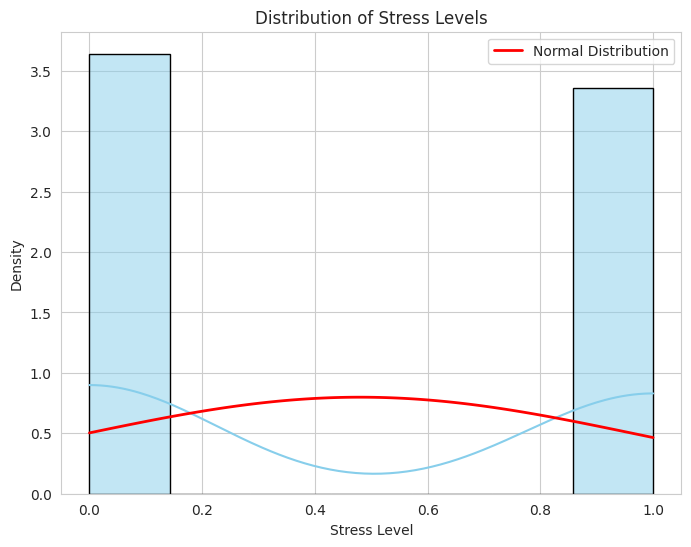

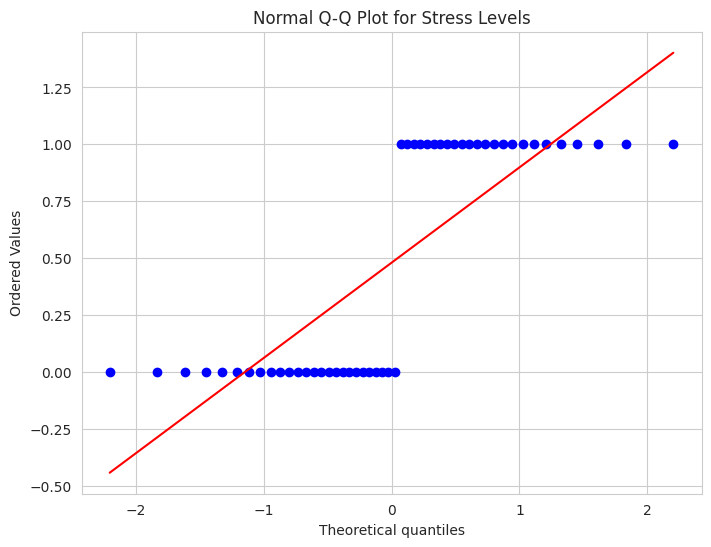

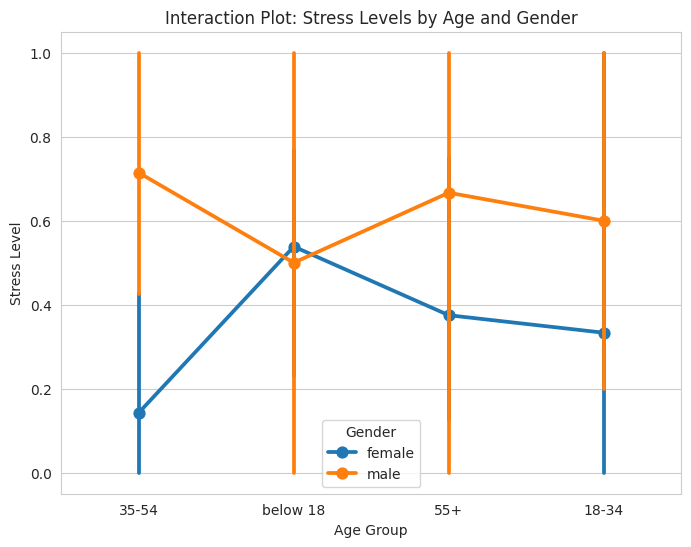

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# Create a histogram with a normal distribution curve overlay
plt.figure(figsize=(8, 6))
sns.histplot(data['Stress'], stat='density', kde=True, color='skyblue', edgecolor='black')
mu, sigma = np.mean(data['Stress']), np.std(data['Stress'])
x = np.linspace(min(data['Stress']), max(data['Stress']), 100)
plt.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(-(x - mu)**2 / (2 * sigma**2)), 'r-', linewidth=2, label='Normal Distribution')
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Density')
plt.legend()
plt.show()

# Create a Q-Q plot for Stress levels
plt.figure(figsize=(8, 6))
stats.probplot(data['Stress'], plot=plt)
plt.title('Normal Q-Q Plot for Stress Levels')
plt.show()

# Create an interaction plot for Stress levels by Age and Gender
plt.figure(figsize=(8, 6))
sns.pointplot(x='Age', y='Stress', hue='Gender', data=data, join=True)
plt.title('Interaction Plot: Stress Levels by Age and Gender')
plt.xlabel('Age Group')
plt.ylabel('Stress Level')
plt.show()

Summary of the different graphs used below:

**Pie Chart**:
The pie chart is used to visualize the distribution of categorical variables, in this case, the distribution of stress levels. It shows the proportion or percentage of each stress level category (e.g., low, moderate, high) in the dataset. Pie charts are useful for presenting data in a simple and intuitive way, making it easy to grasp the relative proportions of different categories.

**Scatter Plot**:
A scatter plot is used to visualize the relationship between two continuous variables. In the provided code, a scatter plot is created to display the relationship between age, stress levels, and gender. Each data point represents an individual, and the plot shows how stress levels vary with age, with different colors representing different genders. Scatter plots are useful for identifying patterns, trends, and potential correlations between variables.

**Line Plot**:
Similar to the scatter plot, a line plot is used to visualize the relationship between two continuous variables, but it connects the data points with lines. In the provided code, a line plot is created to show the trend of stress levels across different age groups, with lines colored based on ethnicity. Line plots are particularly useful for visualizing time-series data or data with a natural ordering, such as age groups.

**Box Plot**:
A box plot is used to visualize the distribution of a continuous variable across different categories or groups. In the provided code, a box plot is created to display the distribution of stress levels across different educational backgrounds, with boxes colored based on geographic location. Box plots provide a compact representation of the central tendency (median), spread (interquartile range), and potential outliers within each group, making it easy to compare distributions across multiple groups.

**Violin Plot**:
Similar to a box plot, a violin plot visualizes the distribution of a continuous variable across different categories or groups. However, instead of using boxes, it uses kernel density estimation to create a violin-shaped representation of the distribution. In the provided code, a violin plot is created to show the distribution of stress levels by gender, with violins colored based on ethnicity. Violin plots are useful for comparing the overall shape and modality of distributions across groups.

**Sunburst Chart**:
A sunburst chart is a hierarchical visualization used to represent nested or hierarchical data. In the provided code, a sunburst chart is created to display the hierarchical view of stress levels by ethnicity, geographic location, and educational background. Each level of the hierarchy is represented by a concentric ring, and the size of the slices within each ring corresponds to the values of stress levels for that particular combination of categories. Sunburst charts are useful for exploring and analyzing hierarchical data structures.

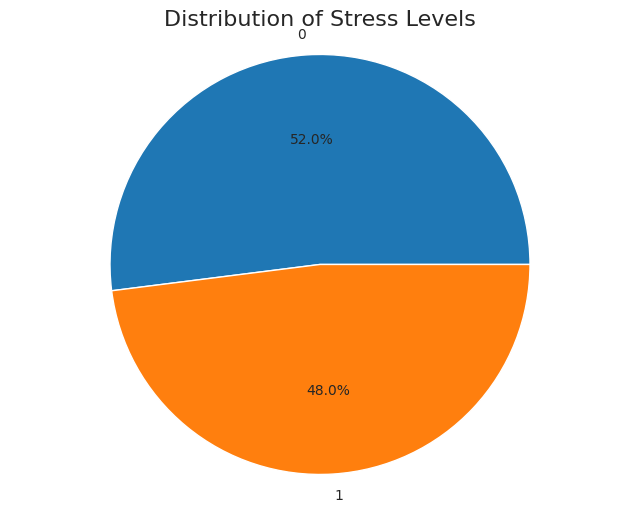

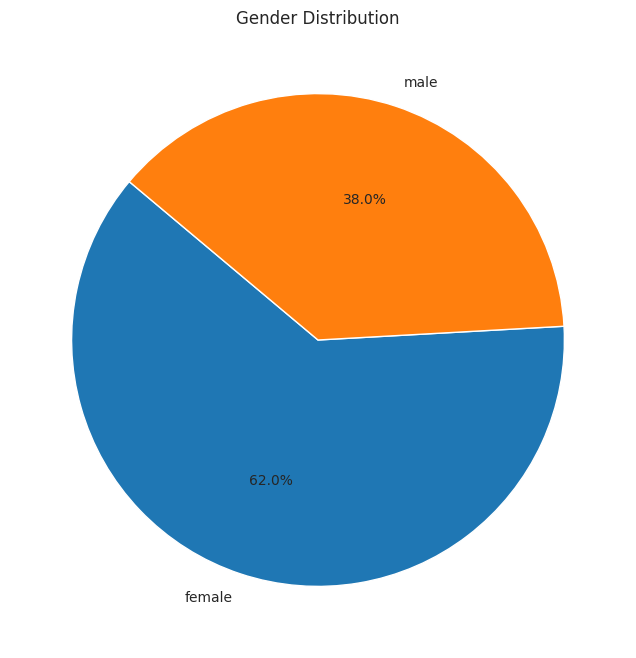

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Count the number of instances for each stress level
stress_counts = data['Stress'].value_counts()

# Create a pie chart
fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(stress_counts, labels=stress_counts.index, autopct='%1.1f%%')
ax.axis('equal')  # Equal aspect ratio ensures the pie chart is drawn as a circle
ax.set_title('Distribution of Stress Levels', fontsize=16)
plt.show()

# Define the demographic parameters
ages = ['below 18', '18-34', '35-54', '55+']
genders = ['male', 'female']
ethnicities = ['Hindu', 'Islam', 'Punjabi', 'Jain']
geographic_locations = ['Jharkhand'] + ['Uttar Pradesh', 'Maharashtra', 'Bihar', 'West Bengal', 'Madhya Pradesh', 'Tamil Nadu', 'Rajasthan', 'Karnataka', 'Gujarat', 'Andhra Pradesh', 'Odisha', 'Telangana', 'Kerala', 'Assam', 'Punjab', 'Chhattisgarh', 'Haryana', 'Uttarakhand', 'Himachal Pradesh', 'Tripura', 'Meghalaya', 'Manipur', 'Nagaland', 'Goa', 'Arunachal Pradesh', 'Mizoram', 'Sikkim', 'Delhi', 'Puducherry']
educational_backgrounds = ['10th pass', '12th pass', 'graduate', 'post graduate']

# Replace numerical values with actual names for categorical variables
data['Age'] = data['Age'].replace({0: ages[0], 1: ages[1], 2: ages[2], 3: ages[3]})
data['Gender'] = data['Gender'].replace({0: genders[0], 1: genders[1]})
data['Ethnicity'] = data['Ethnicity'].replace({0: ethnicities[0], 1: ethnicities[1], 2: ethnicities[2], 3: ethnicities[3]})
data['Geographic_location'] = data['Geographic_location'].replace({i: geographic_locations[i] for i in range(len(geographic_locations))})
data['Educational_background'] = data['Educational_background'].replace({0: educational_backgrounds[0], 1: educational_backgrounds[1], 2: educational_backgrounds[2], 3: educational_backgrounds[3]})
#data['Stress'] = data['Stress'].replace({0: 'Low', 1: 'High'})

plt.figure(figsize=(8, 8))
gender_counts = data['Gender'].value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Gender Distribution')
plt.show()

'''# Scatter Plot
fig = px.scatter(data, x='Age', y='Stress', color='Gender', title='Relationship between Age, Stress, and Gender')
fig.show()

# Line Plot
fig = px.line(data, x='Age', y='Stress', color='Ethnicity', title='Stress Levels by Age and Ethnicity')
fig.show()'''

# Box Plot
fig = px.box(data, x='Educational_background', y='Stress', color='Geographic_location', title='Stress Levels by Education and Location')
fig.show()

# Violin Plot
fig = px.violin(data, y='Stress', x='Gender', color='Ethnicity', title='Distribution of Stress Levels by Gender and Ethnicity')
fig.show()

# Sunburst Chart
fig = px.sunburst(data, path=['Ethnicity', 'Geographic_location', 'Educational_background'], values='Stress', title='Hierarchical View of Stress Levels')
fig.show()

# Data Preprocessing

In [ ]:
path = '/content/teen_dataset/dataset_teen'
all_files = glob.glob(os.path.join(path, "*.csv"))

data_frames = []
for file in all_files:
    df = pd.read_csv(file)
    data_frames.append(df)

# Concatenate all data frames
data = pd.concat(data_frames, axis=0, ignore_index=True)
data

,Timestamp,ECG,EDA,TEMP,CONDITION
0,0.000000,-0.179427,5.000000,37.000000,0
1,0.100334,1.006096,4.983400,37.000630,0
2,0.200669,0.323444,4.996792,37.001261,0
3,0.301003,0.921199,5.037055,37.001891,0
4,0.401338,1.299113,5.026881,37.002521,0
...,...,...,...,...,...
44995,89.599332,-1.157533,10.896857,37.439204,1
44996,89.699499,0.804004,10.935328,37.439705,1
44997,89.799666,-0.734803,10.941574,37.440208,1
44998,89.899833,-0.799494,10.904091,37.440713,1


In [ ]:
# Drop any rows with missing values
data.dropna(inplace=True)

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
data[['ECG', 'EDA', 'TEMP']] = scaler.fit_transform(data[['ECG', 'EDA', 'TEMP']])

# Feature Engineering

| Domain | Feature | Description |
| --- | --- | --- |
| Time-Domain Features | Mean | The average value of the signal. |
|  | Standard Deviation (std) | A measure of the amount of variation or dispersion of a set of values. |
|  | Minimum (min) | The smallest value in the signal. |
|  | Maximum (max) | The largest value in the signal. |
|  | Signal Energy | The total magnitude of the signal, calculated as the sum of the squares of its values. |
|  | Mean Absolute Deviation (MAD) | The average absolute difference between each value and the mean. |
|  | Root Mean Square (RMS) | The square root of the average of the squares of the values. |
|  | Peak-to-Peak (P2P) | The difference between the maximum and minimum values in the signal. |
|  | Zero Crossing Rate | number of zero crossings normalized by the length of the segment |
|  | Shannon Entropy | entropy of unique values |
| Additional Statistical Features | Skewness | only if std > 1e-10 |
|  | Kurtosis | only if std > 1e-10 |
| Frequency-Domain Features (using Welch's method) | Total Power | sum of Pxx |
|  | Frequency with Maximum Power | index of maximum Pxx |
|  | Mean Frequency | mean of f * Pxx normalized by total power, if total power > 0 |
|  | Median Frequency | interpolated frequency at half total power, if total power > 0 |
|  | Spectral Entropy | entropy of Pxx, if total power > 0 |
|  | Spectral Centroid | mean of f * Pxx normalized by total power, if total power > 0 |
| Frequency Band Energy Features: | Delta Band Energy | sum of Pxx in 0.5-4 Hz |
|  | Theta Band Energy | sum of Pxx in 4-8 Hz |
|  | Alpha Band Energy | sum of Pxx in 8-13 Hz |
|  | Beta Band Energy | sum of Pxx in 13-30 Hz |
|  | Gamma Band Energy | sum of Pxx above 30 Hz |
| Time-Frequency Features: | Short-Time Fourier Transform (STFT) Energy | sum of squared magnitudes of Zxx |
|  | Instantaneous Frequency | mean of the instantaneous frequency calculated from the analytic signal |
|  | Continuous Wavelet Transform (CWT) Coefficients Energy | sum of absolute values of CWT coefficients |
|  | Hilbert Transform Energy | sum of absolute values of the Hilbert transform |



Feature Extraction

In [ ]:
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import welch, stft, hilbert, cwt, ricker

# Feature Extraction Function
def extract_features(segment):
    features = []
    for col in segment.columns:
        noisy_segment = segment[col] + np.random.normal(0, 1e-10, segment[col].shape)

        # Time-domain features
        features.append(segment[col].mean())
        features.append(segment[col].std())
        features.append(segment[col].min())
        features.append(segment[col].max())
        features.append(np.sum(segment[col]**2))  # Signal Energy
        features.append(np.mean(np.abs(segment[col] - np.mean(segment[col]))))  # MAD
        features.append(np.sqrt(np.mean(segment[col]**2)))  # RMS
        features.append(segment[col].max() - segment[col].min())  # P2P

        zero_crossings = np.where(np.diff(np.sign(segment[col])))[0]
        features.append(len(zero_crossings) / float(len(segment[col])))

        value, counts = np.unique(segment[col], return_counts=True)
        features.append(entropy(counts))

        if segment[col].std() > 1e-10:
            features.append(skew(noisy_segment))
            features.append(kurtosis(noisy_segment))
        else:
            features.extend([0, 0])

        # Frequency-domain features using Welch's method
        f, Pxx = welch(segment[col], fs=1.0, nperseg=min(256, len(segment[col])))
        features.append(np.sum(Pxx))  # Total power
        features.append(np.argmax(Pxx))  # Frequency with maximum power

        # Additional frequency-domain features
        total_power = np.sum(Pxx)
        if total_power > 0:
            features.append(np.mean(f * Pxx) / total_power)  # Mean Frequency
            median_freq = np.interp(total_power / 2.0, np.cumsum(Pxx), f)
            features.append(median_freq)  # Median Frequency
            features.append(entropy(Pxx))  # Spectral Entropy
            features.append(np.sum(f * Pxx) / total_power)  # Spectral Centroid
        else:
            features.extend([0, 0, 0, 0])

        features.append(np.sum(Pxx[(f >= 0.5) & (f < 4)]))  # Delta Band Energy
        features.append(np.sum(Pxx[(f >= 4) & (f < 8)]))  # Theta Band Energy
        features.append(np.sum(Pxx[(f >= 8) & (f < 13)]))  # Alpha Band Energy
        features.append(np.sum(Pxx[(f >= 13) & (f < 30)]))  # Beta Band Energy
        features.append(np.sum(Pxx[(f >= 30)]))  # Gamma Band Energy

        # Time-Frequency features
        f_stft, t_stft, Zxx = stft(segment[col], nperseg=min(256, len(segment[col])))
        features.append(np.sum(np.abs(Zxx)**2))  # STFT Energy

        analytic_signal = hilbert(segment[col])
        instantaneous_frequency = np.diff(np.unwrap(np.angle(analytic_signal)))
        features.append(np.mean(instantaneous_frequency))  # Instantaneous Frequency

        widths = np.arange(1, 31)
        cwt_matr = cwt(segment[col], ricker, widths)
        features.append(np.sum(np.abs(cwt_matr)))  # Wavelet Coefficients Energy
        features.append(np.sum(np.abs(hilbert(segment[col]))))  # Hilbert Transform Energy

    return features


Sequence Preparation with Feature Extraction : Assuming each subject's data is sequentially organized we are creating sequences for each subject

In [ ]:
def create_sequences_with_features(data, sequence_length):
    sequences = []
    labels = []
    for i in range(0, len(data) - sequence_length):
        segment = data[['ECG', 'EDA', 'TEMP']].iloc[i:i + sequence_length]
        label = data['CONDITION'].iloc[i + sequence_length - 1]

        # Extract features from the segment
        features = extract_features(segment)
        sequences.append(features)
        labels.append(label)

    return np.array(sequences), np.array(labels)

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

sequence_length = 50
X, y = create_sequences_with_features(data, sequence_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Selection

• Relief F

• Select k-Best

Relief F

In [ ]:
!pip install ReliefF

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for ReliefF: filename=ReliefF-0.1.2-py3-none-any.whl size=6303 sha256=5ea4a615c44472234eac09c9fa86cb995661f92cf4b3a8be18839a21941ea929
  Stored in directory: /root/.cache/pip/wheels/35/bc/0b/14a0227d4829b6b27f25de250213eb348b094d075be7604707
Successfully built ReliefF


In [ ]:
from ReliefF import ReliefF

# Initialize ReliefF with the number of features to select
relief = ReliefF(n_features_to_keep=15)  # Select top 15 features

# Fit the ReliefF model to the data
X_train_selected = relief.fit_transform(X_train, y_train)
X_test_selected = relief.transform(X_test)

# Get the selected features
selected_indices = relief.top_features
print("Selected Features:", selected_indices)

Selected Features: [62 20  9 47 46 22 63 21 49 19 48 73 74 75 76 35  8 67 36 40 13 57 56  2
  3 61  7 29 30 69 79 80 66 54 60 78 77 68 59 58 55 72 71 70 34 42 65  6
 10 11 12  5  4 14 15 16 17 18  1 50 24 64 23 52 45 44 43 41 53 39 38 37
 33 32 31 28 27 26 25 51  0]


In [ ]:
X_test_selected.shape

(8990, 15)

In [ ]:
'''from pymrmr import mRMR

def mrmr_feature_selection(X_train, y_train, k):
    feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
    X_train_df = pd.DataFrame(X_train, columns=feature_names)
    y_train_df = pd.Series(y_train, name='target')
    data = pd.concat([X_train_df, y_train_df], axis=1)

    selected_features = mRMR(data, 'MIQ', k)
    selected_feature_indices = [int(f.split('_')[1]) for f in selected_features]

    return selected_feature_indices

c = 15  # Number of top features to select
selected_indices = mrmr_feature_selection(X_train, y_train, c)

X_train_selected = X_train[:, selected_indices]
X_test_selected = X_test[:, selected_indices]'''

# Classification Models

Classification ML :  SVM,  RF,  DT, extreme boosting, MNB, boot aggregation, Gaussian NB, MLPNN,RBFNN

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': (LogisticRegression(), {'C': [0.1, 1, 10], 'penalty': ['l1', 'l2', 'elasticnet', 'none'], 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}),
    'SVM': (SVC(), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [10, 100, 200], 'max_depth': [None, 10, 20], 'criterion': ['gini', 'entropy']}),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {'max_depth': [None, 10, 20], 'max_features': [0.5, 0.7, 1.0], 'criterion': ['gini', 'entropy']}),
    'Gradient Boosting': (GradientBoostingClassifier(random_state=42), {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1], 'max_features': [0.5, 0.7, 1.0],  'subsample': [0.5, 0.7, 1.0]}),
    'Bagging Classifier': (BaggingClassifier(random_state=42), {'n_estimators': [10, 50, 100], 'max_features': [0.5, 0.7, 1.0]}),
    'Multinomial NB': (MultinomialNB(), {'alpha': [0.1, 1, 10], 'fit_prior': [True, False]}),
    'Gaussian NB': (GaussianNB(), {'var_smoothing': [1e-9, 1e-8, 1e-7]})
}

Training ML Models:   0%|          | 0/8 [00:00<?, ?it/s]

Perfomance Metrics for Logistic Regression
Logistic Regression Best Params: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Logistic Regression Accuracy: 0.67
Logistic Regression Precision: 0.45
Logistic Regression Recall: 0.67
Logistic Regression F1 Score: 0.54


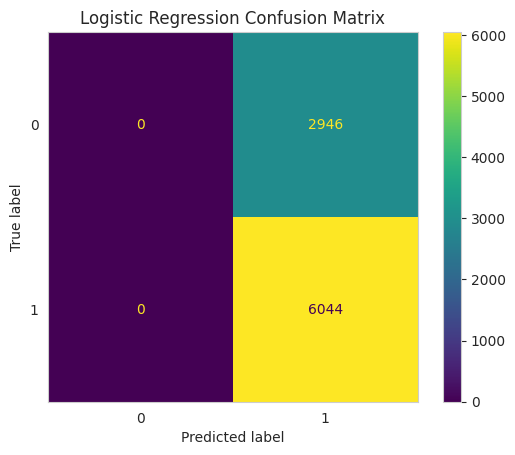

Training ML Models:  12%|█▎        | 1/8 [00:53<06:16, 53.79s/it]

Perfomance Metrics for SVM
SVM Best Params: {'C': 0.1, 'kernel': 'linear'}
SVM Accuracy: 0.67
SVM Precision: 0.45
SVM Recall: 0.67
SVM F1 Score: 0.54


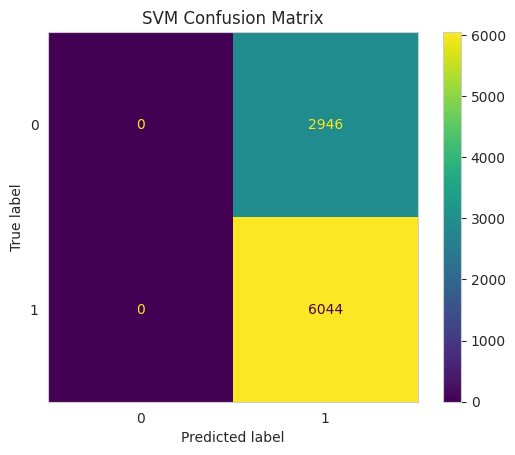

Training ML Models:  25%|██▌       | 2/8 [15:18<53:06, 531.06s/it]

Perfomance Metrics for Random Forest
Random Forest Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}
Random Forest Accuracy: 0.67
Random Forest Precision: 0.45
Random Forest Recall: 0.67
Random Forest F1 Score: 0.54


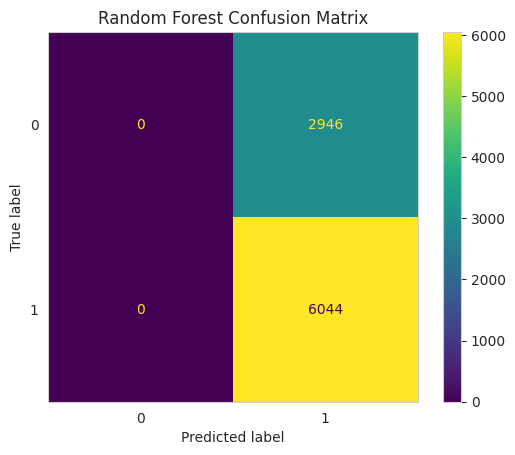

Training ML Models:  38%|███▊      | 3/8 [16:24<26:32, 318.54s/it]

Perfomance Metrics for Decision Tree
Decision Tree Best Params: {'criterion': 'gini', 'max_depth': None, 'max_features': 0.5}
Decision Tree Accuracy: 0.67
Decision Tree Precision: 0.45
Decision Tree Recall: 0.67
Decision Tree F1 Score: 0.54


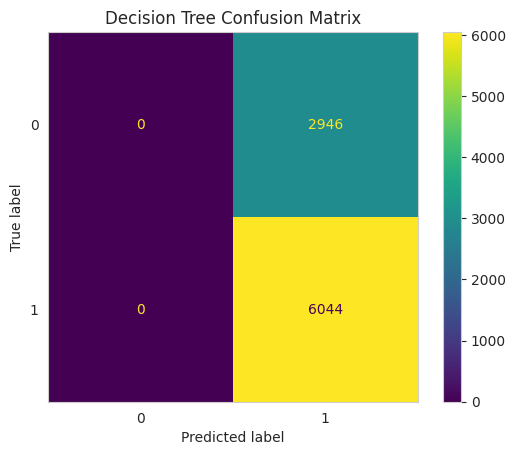

Training ML Models:  50%|█████     | 4/8 [16:25<12:52, 193.25s/it]

Perfomance Metrics for Gradient Boosting
Gradient Boosting Best Params: {'learning_rate': 0.01, 'max_features': 0.5, 'n_estimators': 100, 'subsample': 0.5}
Gradient Boosting Accuracy: 0.67
Gradient Boosting Precision: 0.45
Gradient Boosting Recall: 0.67
Gradient Boosting F1 Score: 0.54


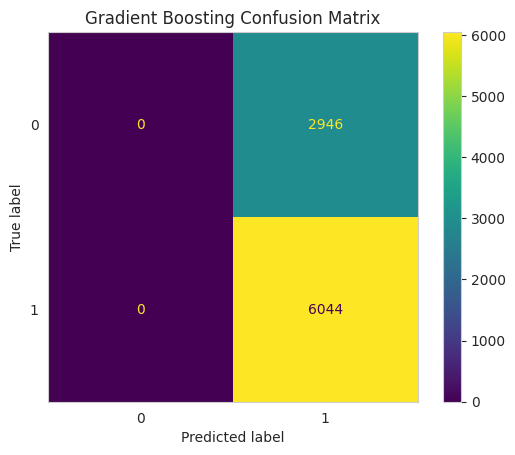

Training ML Models:  62%|██████▎   | 5/8 [19:53<09:55, 198.55s/it]

Perfomance Metrics for Bagging Classifier
Bagging Classifier Best Params: {'max_features': 0.5, 'n_estimators': 10}
Bagging Classifier Accuracy: 0.67
Bagging Classifier Precision: 0.45
Bagging Classifier Recall: 0.67
Bagging Classifier F1 Score: 0.54


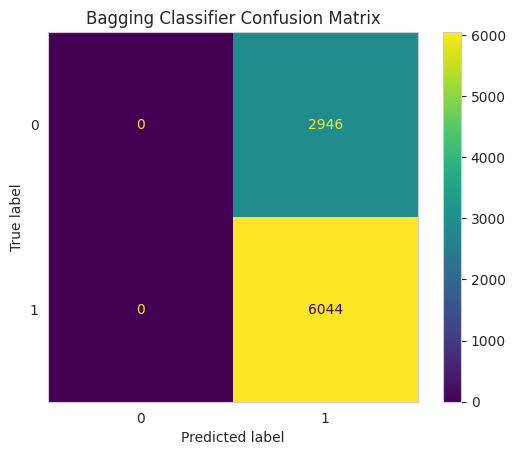

Training ML Models:  75%|███████▌  | 6/8 [20:14<04:36, 138.05s/it]

Perfomance Metrics for Multinomial NB
Multinomial NB Best Params: {'alpha': 0.1, 'fit_prior': True}
Multinomial NB Accuracy: 0.67
Multinomial NB Precision: 0.45
Multinomial NB Recall: 0.67
Multinomial NB F1 Score: 0.54


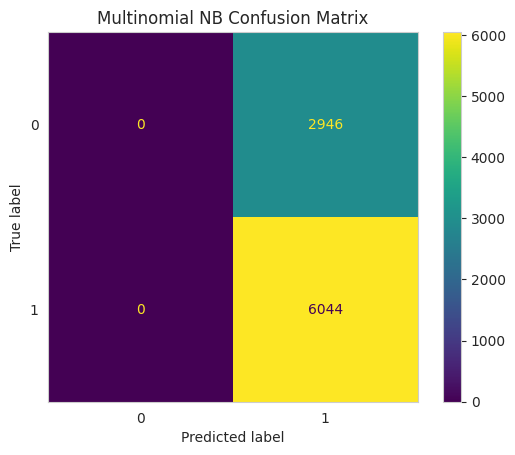

Training ML Models:  88%|████████▊ | 7/8 [20:15<01:33, 93.15s/it] 

Perfomance Metrics for Gaussian NB
Gaussian NB Best Params: {'var_smoothing': 1e-09}
Gaussian NB Accuracy: 0.72
Gaussian NB Precision: 0.80
Gaussian NB Recall: 0.72
Gaussian NB F1 Score: 0.64


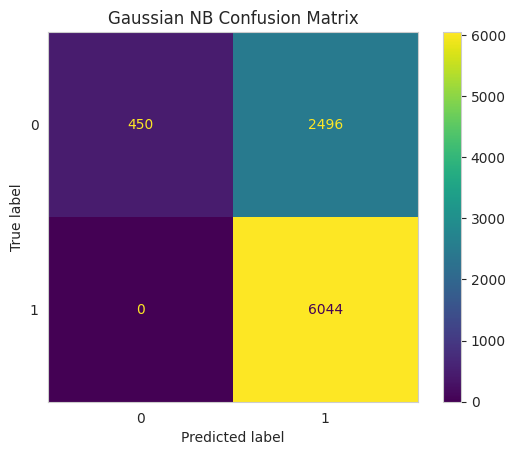

Training ML Models: 100%|██████████| 8/8 [20:15<00:00, 151.95s/it]


In [ ]:
from tqdm import tqdm
results = []

#for name, (model, params) in models.items():
for name, (model, params) in tqdm(models.items(), desc="Training ML Models"):
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid_search.fit(scaler.fit_transform(X_train_selected), y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'Perfomance Metrics for {name}')
    print(f'{name} Best Params: {grid_search.best_params_}')
    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.grid(False)
    plt.show()

# Deep Learning Models

Deep Learning Models - LSTM, RNN, 1D-CNN, MLPNN, RBFNN

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, LSTM, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping

deep_learning_models = {
    '1D CNN': Sequential([
        Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_selected.shape[1], 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(1, activation='sigmoid')
    ]),
    'LSTM': Sequential([
        LSTM(50, activation='relu', input_shape=(X_train_selected.shape[1], 1)),
        Dense(1, activation='sigmoid')
    ]),
    'RNN': Sequential([
        SimpleRNN(50, activation='relu', input_shape=(X_train_selected.shape[1], 1)),
        Dense(1, activation='sigmoid')
    ]),
    'MLPNN': Sequential([
        Dense(64, activation='relu', input_shape=(X_train_selected.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
}

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1D CNN Accuracy: 0.72
1D CNN Precision: 0.80
1D CNN Recall: 0.72
1D CNN F1 Score: 0.64


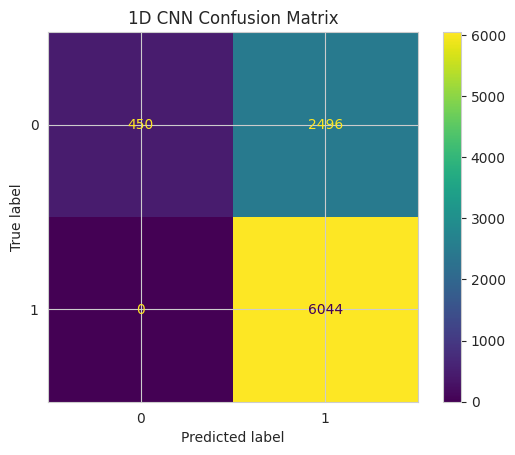

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Accuracy: 0.72
LSTM Precision: 0.80
LSTM Recall: 0.72
LSTM F1 Score: 0.64


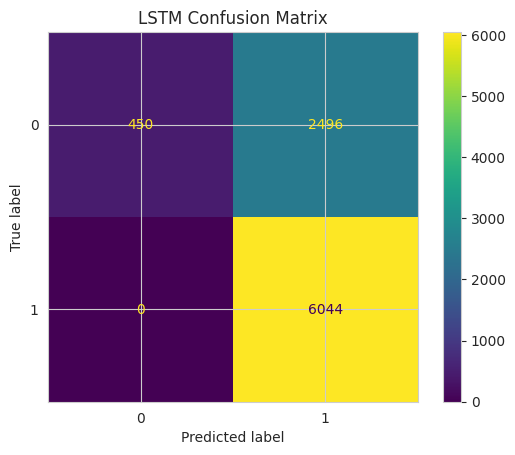

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
RNN Accuracy: 0.72
RNN Precision: 0.80
RNN Recall: 0.72
RNN F1 Score: 0.64


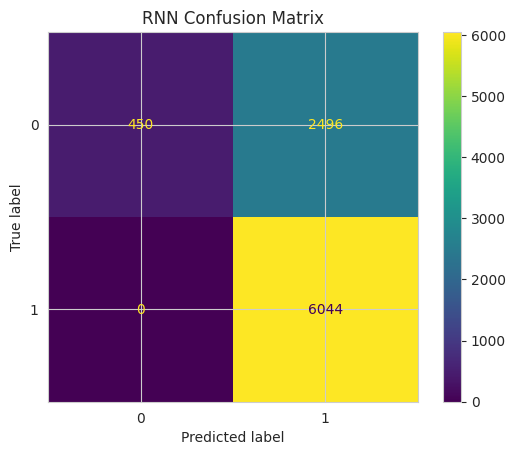

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MLPNN Accuracy: 0.72
MLPNN Precision: 0.80
MLPNN Recall: 0.72
MLPNN F1 Score: 0.64


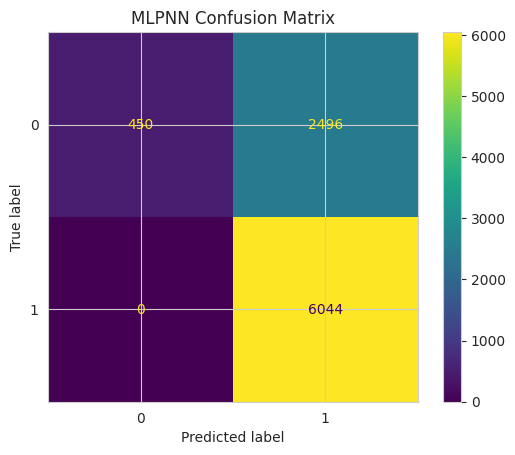

In [ ]:
# Deep Learning Models
X_train_selected_dl = X_train_selected.reshape((X_train_selected.shape[0], X_train_selected.shape[1], 1))
X_test_selected_dl = X_test_selected.reshape((X_test_selected.shape[0], X_test_selected.shape[1], 1))

for name, model in deep_learning_models.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train_selected_dl, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    y_pred = (model.predict(X_test_selected_dl) > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': 'N/A',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class RBFNN:
    def __init__(self, num_centers, gamma=None):
        self.num_centers = num_centers
        self.centers = None
        self.gamma = gamma
        self.weights = None

    def _rbf(self, X, centers):
        if self.gamma is None:
            dists = cdist(X, centers, 'euclidean')
            self.gamma = 1.0 / (2 * np.mean(dists) ** 2)
        return np.exp(-self.gamma * cdist(X, centers, 'euclidean') ** 2)

    def fit(self, X, y):
        # Step 1: KMeans to find centers
        kmeans = KMeans(n_clusters=self.num_centers, random_state=42).fit(X)
        self.centers = kmeans.cluster_centers_

        # Step 2: Calculate RBFs
        R = self._rbf(X, self.centers)

        # Step 3: Fit linear model
        self.weights = Ridge(alpha=1.0, random_state=42).fit(R, y).coef_

    def predict(self, X):
        R = self._rbf(X, self.centers)
        return np.dot(R, self.weights.T)

# Example usage:
# Assuming X_train_selected and y_train are your training data
num_centers = 10
name = 'RBFNN'
rbfnn = RBFNN(num_centers=num_centers)
rbfnn.fit(X_train_selected, y_train)

y_test_pred = rbfnn.predict(X_test_selected)
y_test_pred = np.round(y_test_pred).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

results.append({
        'Model': name,
        'Best Params': 'N/A',
        'Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1 Score': test_f1
    })

print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")

Test Accuracy: 0.72
Test Precision: 0.80
Test Recall: 0.72
Test F1 Score: 0.64


Results Summary

In [ ]:
from tabulate import tabulate

summary_df = pd.DataFrame(results)
headers = ["Model", "Best Params", "Accuracy", "Precision", "Recall", "F1 Score"]
print("Model Performance when mRMR as feature selection technique is used")
print(tabulate(summary_df, headers, tablefmt="pretty"))

Model Performance when mRMR as feature selection technique is used
+----+---------------------+-------------------------------------------------------------------------------------+--------------------+---------------------+--------------------+--------------------+
|    |        Model        |                                     Best Params                                     |      Accuracy      |      Precision      |       Recall       |      F1 Score      |
+----+---------------------+-------------------------------------------------------------------------------------+--------------------+---------------------+--------------------+--------------------+
| 0  | Logistic Regression |                 {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}                  | 0.6723025583982203 | 0.45199073002879236 | 0.6723025583982203 | 0.5405609502406337 |
| 1  |         SVM         |                           {'C': 0.1, 'kernel': 'linear'}                            | 0.6723025583982203

# Classification after K-Best feature selection method

In [ ]:
from sklearn.model_selection import train_test_split

sequence_length = 50
X, y = create_sequences_with_features(data, sequence_length)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor

k = 15  # Number of top features to select
selector = SelectKBest(mutual_info_classif, k=k)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [ ]:
X_test_selected.shape

(8990, 15)

Training ML Models:   0%|          | 0/8 [00:00<?, ?it/s]

Perfomance Metrics for Logistic Regression
Logistic Regression Best Params: {'C': 0.1, 'penalty': 'none', 'solver': 'newton-cg'}
Logistic Regression Accuracy: 0.33
Logistic Regression Precision: 0.11
Logistic Regression Recall: 0.33
Logistic Regression F1 Score: 0.16


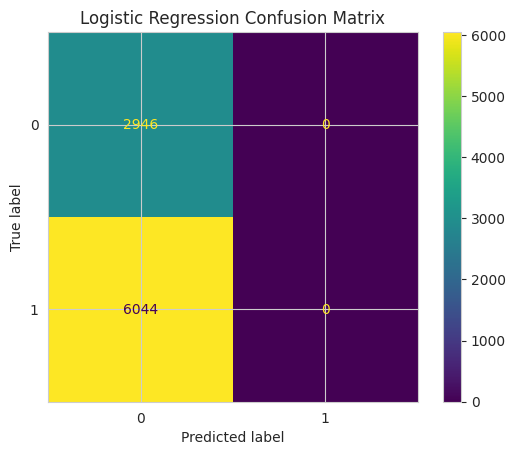

Training ML Models:  12%|█▎        | 1/8 [02:21<16:28, 141.22s/it]

Perfomance Metrics for SVM
SVM Best Params: {'C': 0.1, 'kernel': 'rbf'}
SVM Accuracy: 0.67
SVM Precision: 0.45
SVM Recall: 0.67
SVM F1 Score: 0.54


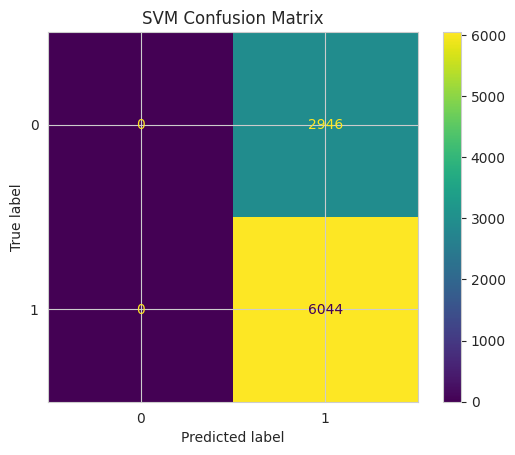

Training ML Models:  25%|██▌       | 2/8 [03:18<09:09, 91.56s/it] 

Perfomance Metrics for Random Forest
Random Forest Best Params: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 10}
Random Forest Accuracy: 0.84
Random Forest Precision: 0.89
Random Forest Recall: 0.84
Random Forest F1 Score: 0.84


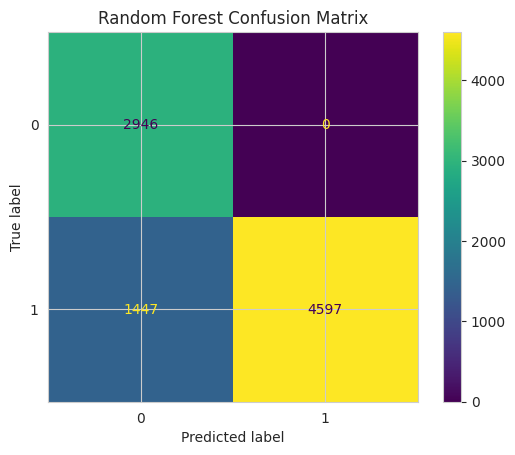

Training ML Models:  38%|███▊      | 3/8 [05:53<10:04, 120.93s/it]

Perfomance Metrics for Decision Tree
Decision Tree Best Params: {'criterion': 'gini', 'max_depth': None, 'max_features': 0.5}
Decision Tree Accuracy: 0.33
Decision Tree Precision: 0.11
Decision Tree Recall: 0.33
Decision Tree F1 Score: 0.16


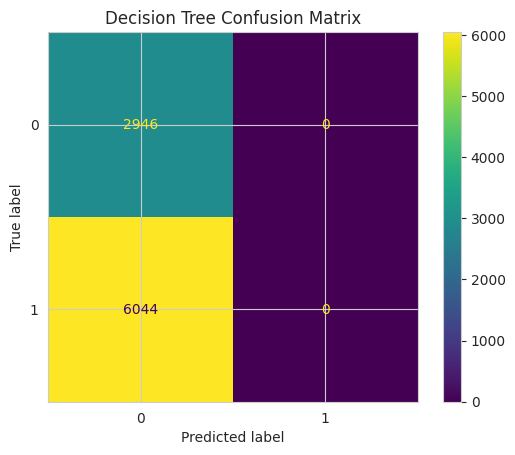

Training ML Models:  50%|█████     | 4/8 [05:59<05:01, 75.27s/it] 

Perfomance Metrics for Gradient Boosting
Gradient Boosting Best Params: {'learning_rate': 0.01, 'max_features': 0.5, 'n_estimators': 100, 'subsample': 0.5}
Gradient Boosting Accuracy: 0.98
Gradient Boosting Precision: 0.98
Gradient Boosting Recall: 0.98
Gradient Boosting F1 Score: 0.98


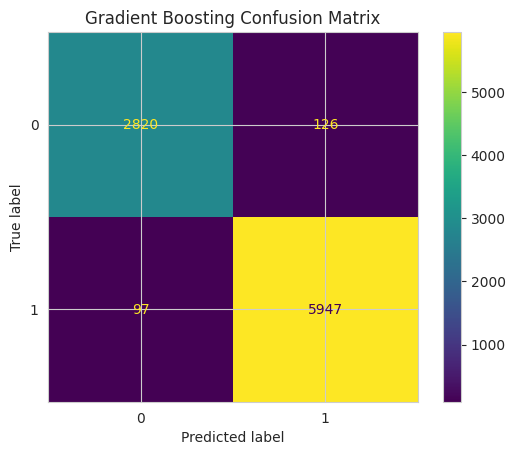

Training ML Models:  62%|██████▎   | 5/8 [28:19<26:33, 531.29s/it]

Perfomance Metrics for Bagging Classifier
Bagging Classifier Best Params: {'max_features': 0.5, 'n_estimators': 10}
Bagging Classifier Accuracy: 0.54
Bagging Classifier Precision: 0.81
Bagging Classifier Recall: 0.54
Bagging Classifier F1 Score: 0.51


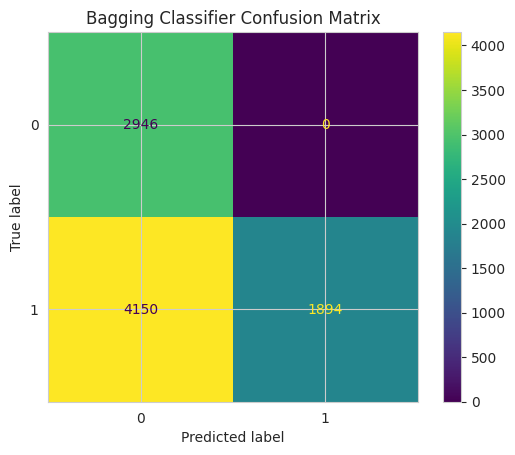

Training ML Models:  75%|███████▌  | 6/8 [30:05<12:53, 386.88s/it]

Perfomance Metrics for Multinomial NB
Multinomial NB Best Params: {'alpha': 0.1, 'fit_prior': False}
Multinomial NB Accuracy: 0.67
Multinomial NB Precision: 0.45
Multinomial NB Recall: 0.67
Multinomial NB F1 Score: 0.54


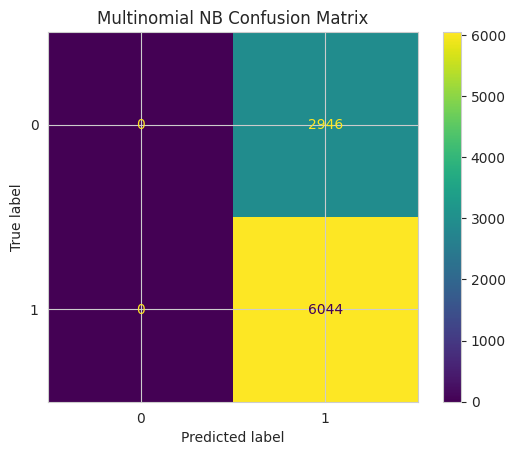

Training ML Models:  88%|████████▊ | 7/8 [30:06<04:20, 260.62s/it]

Perfomance Metrics for Gaussian NB
Gaussian NB Best Params: {'var_smoothing': 1e-09}
Gaussian NB Accuracy: 0.33
Gaussian NB Precision: 0.11
Gaussian NB Recall: 0.33
Gaussian NB F1 Score: 0.16


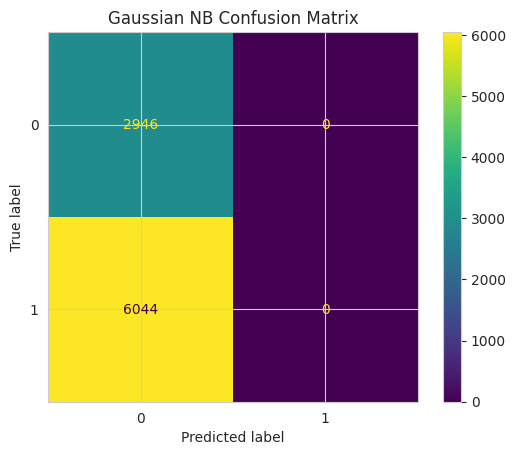

Training ML Models: 100%|██████████| 8/8 [30:06<00:00, 225.86s/it]


In [ ]:
from tqdm import tqdm
results = []

#for name, (model, params) in models.items():
for name, (model, params) in tqdm(models.items(), desc="Training ML Models"):
    grid_search = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid_search.fit(scaler.fit_transform(X_train_selected), y_train)
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test_selected)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'Perfomance Metrics for {name}')
    print(f'{name} Best Params: {grid_search.best_params_}')
    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
1D CNN Accuracy: 1.00
1D CNN Precision: 1.00
1D CNN Recall: 1.00
1D CNN F1 Score: 1.00


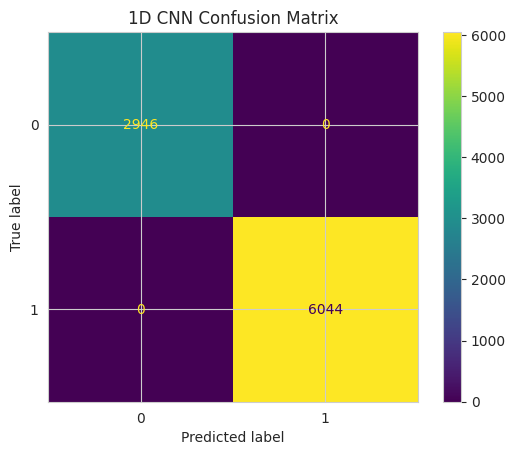

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Accuracy: 1.00
LSTM Precision: 1.00
LSTM Recall: 1.00
LSTM F1 Score: 1.00


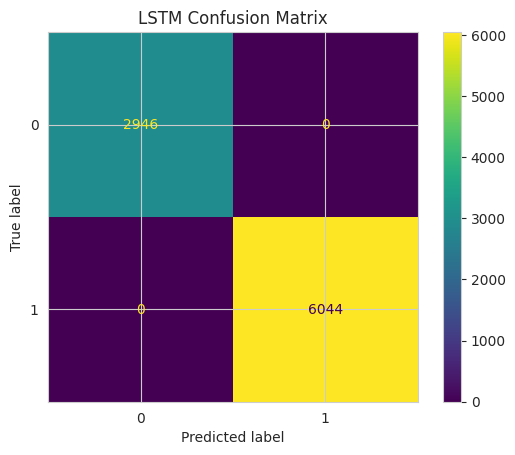

281/281 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
RNN Accuracy: 1.00
RNN Precision: 1.00
RNN Recall: 1.00
RNN F1 Score: 1.00


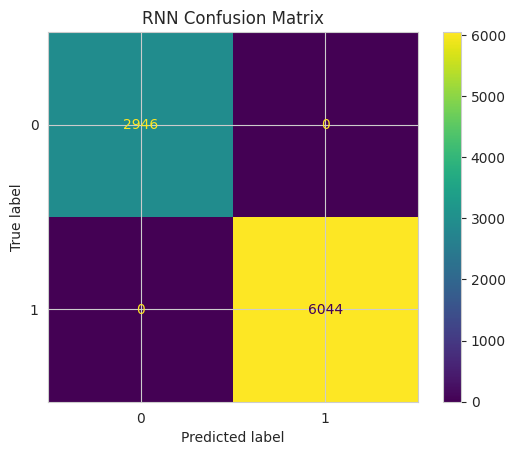

281/281 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MLPNN Accuracy: 1.00
MLPNN Precision: 1.00
MLPNN Recall: 1.00
MLPNN F1 Score: 1.00


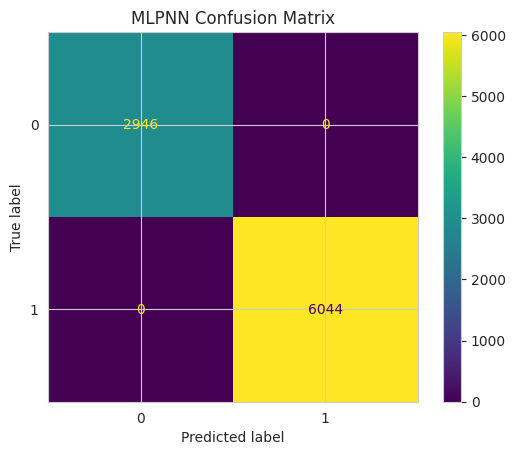

In [ ]:
# Deep Learning Models
X_train_selected_dl = X_train_selected.reshape((X_train_selected.shape[0], X_train_selected.shape[1], 1))
X_test_selected_dl = X_test_selected.reshape((X_test_selected.shape[0], X_test_selected.shape[1], 1))

for name, model in deep_learning_models.items():
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    model.fit(X_train_selected_dl, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=0)
    y_pred = (model.predict(X_test_selected_dl) > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    cm = confusion_matrix(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Params': 'N/A',
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f'{name} Accuracy: {accuracy:.2f}')
    print(f'{name} Precision: {precision:.2f}')
    print(f'{name} Recall: {recall:.2f}')
    print(f'{name} F1 Score: {f1:.2f}')

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [ ]:
num_centers = 10
name = 'RBFNN'
rbfnn = RBFNN(num_centers=num_centers)
rbfnn.fit(X_train_selected, y_train)

y_test_pred = rbfnn.predict(X_test_selected)
y_test_pred = np.round(y_test_pred).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

results.append({
        'Model': name,
        'Best Params': 'N/A',
        'Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1 Score': test_f1
    })

print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test Precision: {test_precision:.2f}")
print(f"Test Recall: {test_recall:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")

Test Accuracy: 0.96
Test Precision: 0.96
Test Recall: 0.96
Test F1 Score: 0.96


In [ ]:
from tabulate import tabulate

summary_df = pd.DataFrame(results)
headers = ["Model", "Best Params", "Accuracy", "Precision", "Recall", "F1 Score"]
print("Model Performance when select K best as feature selection technique is used")
print(tabulate(summary_df, headers, tablefmt="pretty"))

Model Performance when select K best as feature selection technique is used
+----+---------------------+-------------------------------------------------------------------------------------+---------------------+---------------------+---------------------+--------------------+
|    |        Model        |                                     Best Params                                     |      Accuracy       |      Precision      |       Recall        |      F1 Score      |
+----+---------------------+-------------------------------------------------------------------------------------+---------------------+---------------------+---------------------+--------------------+
| 0  | Logistic Regression |                {'C': 0.1, 'penalty': 'none', 'solver': 'newton-cg'}                 | 0.32769744160177977 | 0.10738561323235185 | 0.32769744160177977 | 0.1617621754287606 |
| 1  |         SVM         |                             {'C': 0.1, 'kernel': 'rbf'}                             | 0